In [1]:

!git clone https://github.com/Felix982/XAI-project.git
%cd XAI-project

fatal: destination path 'XAI-project' already exists and is not an empty directory.
/content/XAI-project


In [2]:
!pip install medmnist

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 347 bytes | 115.00 KiB/s, done.
From https://github.com/Felix982/XAI-project
   834466c..3640625  main       -> origin/main
Updating 834466c..3640625
Fast-forward
 sampling/sample_diffusion.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [5]:
!pip install diffusers transformers accelerate tensorboard

In [4]:
import os
from typing import Iterable
import matplotlib.pyplot as plt
from PIL import Image


def delta_to_name(delta: float) -> str:
    """
    Match the naming convention used by the experiment scripts.

    Examples:
        0.1   -> plus_0p100
        -0.2  -> minus_0p200
        0.0   -> plus_0p000
    """
    s = f"{delta:+.3f}"
    return s.replace("+", "plus_").replace("-", "minus_").replace(".", "p")


def display_sampling_comparison(
    deltas: Iterable[float],
    base_output_dir: str = "/content/drive/MyDrive/XAI_project/outputs/experiments",
    class_label: int = 0,
    figsize_per_row: tuple[float, float] = (12, 4.5),
    show_missing: bool = True,
):
    """
    Display saved sampling grids for several deltas.

    Layout:
        one row per delta
        left  = uncorrected
        right = corrected

    Parameters
    ----------
    deltas:
        Iterable of delta values, e.g. [0.0, 0.01, 0.02, -0.02]
    base_output_dir:
        Root experiment directory.
    class_label:
        Class label used in the saved filenames.
    figsize_per_row:
        Base figure size per row as (width, height).
    show_missing:
        If True, missing images are shown as empty panels with a message.
    """
    deltas = list(deltas)
    n = len(deltas)

    if n == 0:
        print("No deltas provided.")
        return

    fig, axes = plt.subplots(
        nrows=n,
        ncols=2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n),
        squeeze=False,
    )

    for row_idx, delta in enumerate(deltas):
        run_name = f"delta_{delta_to_name(delta)}"

        paths = {
            "uncorrected": os.path.join(
                base_output_dir,
                run_name,
                "samples_uncorrected",
                f"samples_class_{class_label}_uncorrected_grid.png",
            ),
            "corrected": os.path.join(
                base_output_dir,
                run_name,
                "samples_corrected",
                f"samples_class_{class_label}_corrected_grid.png",
            ),
        }

        for col_idx, (strategy, path) in enumerate(paths.items()):
            ax = axes[row_idx][col_idx]

            if os.path.exists(path):
                img = Image.open(path)
                ax.imshow(img)
                ax.set_title(f"δ = {delta:+.3f} | {strategy}", fontsize=12)
            else:
                if show_missing:
                    ax.text(
                        0.5,
                        0.5,
                        f"Missing:\n{os.path.basename(path)}",
                        ha="center",
                        va="center",
                        fontsize=11,
                    )
                    ax.set_title(f"δ = {delta:+.3f} | {strategy}", fontsize=12)

            ax.axis("off")

    plt.tight_layout()
    plt.show()

In [5]:
import os

os.makedirs("/content/drive/MyDrive/XAI_project/data", exist_ok=True)
os.makedirs("/content/drive/MyDrive/XAI_project/outputs/experiments", exist_ok=True)

In [12]:
!python -m training.run_delta_sweep \
  --deltas 0.1 0.2 -0.2 \
  --base-output-dir /content/drive/MyDrive/XAI_project/outputs/experiments \
  --data-root /content/drive/MyDrive/XAI_project/data \
  --max-epochs 10 \
  --batch-size 64 \
  --num-workers 2 \
  --seed 42

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Starting training for delta=+0.100
Output dir: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p100/train
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Epoch 001 | train_loss=0.011660 | val_loss=0.011632
Epoch 002 | train_loss=0.010757 | val_loss=0.011123
Epoch 003 | train_loss=0.010475 | val_loss=0.010801
Epoch 004 | train_loss=0.009890 | val_loss=0.009771
Epoch 005 | train_loss=0.009958 | val_loss=0.009138
Epoch 006 | train_loss=0.010564 | val_loss=0.010250
Epo

In [14]:
%load_ext tensorboard
%tensorboard --logdir /content/drive/MyDrive/XAI_project/outputs/experiments

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 12808), started 0:01:42 ago. (Use '!kill 12808' to kill it.)

<IPython.core.display.Javascript object>

In [18]:
!find /content/drive/MyDrive/XAI_project/outputs/experiments -type f | grep tfevents

In [21]:
!python -m sampling.run_visual_comparison \
  --deltas 0.1 0.2 -0.2 \
  --base-output-dir /content/drive/MyDrive/XAI_project/outputs/experiments \
  --batch-size 5 \
  --class-label 0 \
  --seed 123

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Sampling delta=+0.100 | strategy=uncorrected
Checkpoint: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p100/train/diffusion_best.pt
Output dir: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p100/samples_uncorrected
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Sampling delta=+0.100 | strategy=corrected
Checkpoint: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p100/train/diffusion_best.pt
Output dir: /content/drive/MyDri

In [6]:
import os
os.makedirs("/content/drive/MyDrive/XAI_project/data", exist_ok=True)
os.makedirs("/content/drive/MyDrive/XAI_project/outputs/experiments", exist_ok=True)

In [40]:
!python -m training.run_delta_sweep \
  --deltas 0.0 -0.001 0.001 0.003 -0.003 \
  --base-output-dir /content/drive/MyDrive/XAI_project/outputs/experiments \
  --data-root /content/drive/MyDrive/XAI_project/data \
  --max-epochs 3 \
  --batch-size 128 \
  --num-workers 2 \
  --seed 42

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
2026-04-16 06:40:57.537147: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776321657.559172   29544 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776321657.566324   29544 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776321657.584984   29544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid link

In [43]:
!python -m sampling.run_visual_comparison \
  --deltas 0.0 -0.001 0.001 0.003 -0.003 \
  --base-output-dir /content/drive/MyDrive/XAI_project/outputs/experiments \
  --batch-size 5 \
  --class-label 0 \
  --seed 123

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Sampling delta=+0.000 | strategy=uncorrected
Checkpoint: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p000/train/diffusion_best.pt
Output dir: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p000/samples_uncorrected
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Sampling delta=+0.000 | strategy=corrected
Checkpoint: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p000/train/diffusion_best.pt
Output dir: /content/drive/MyDri

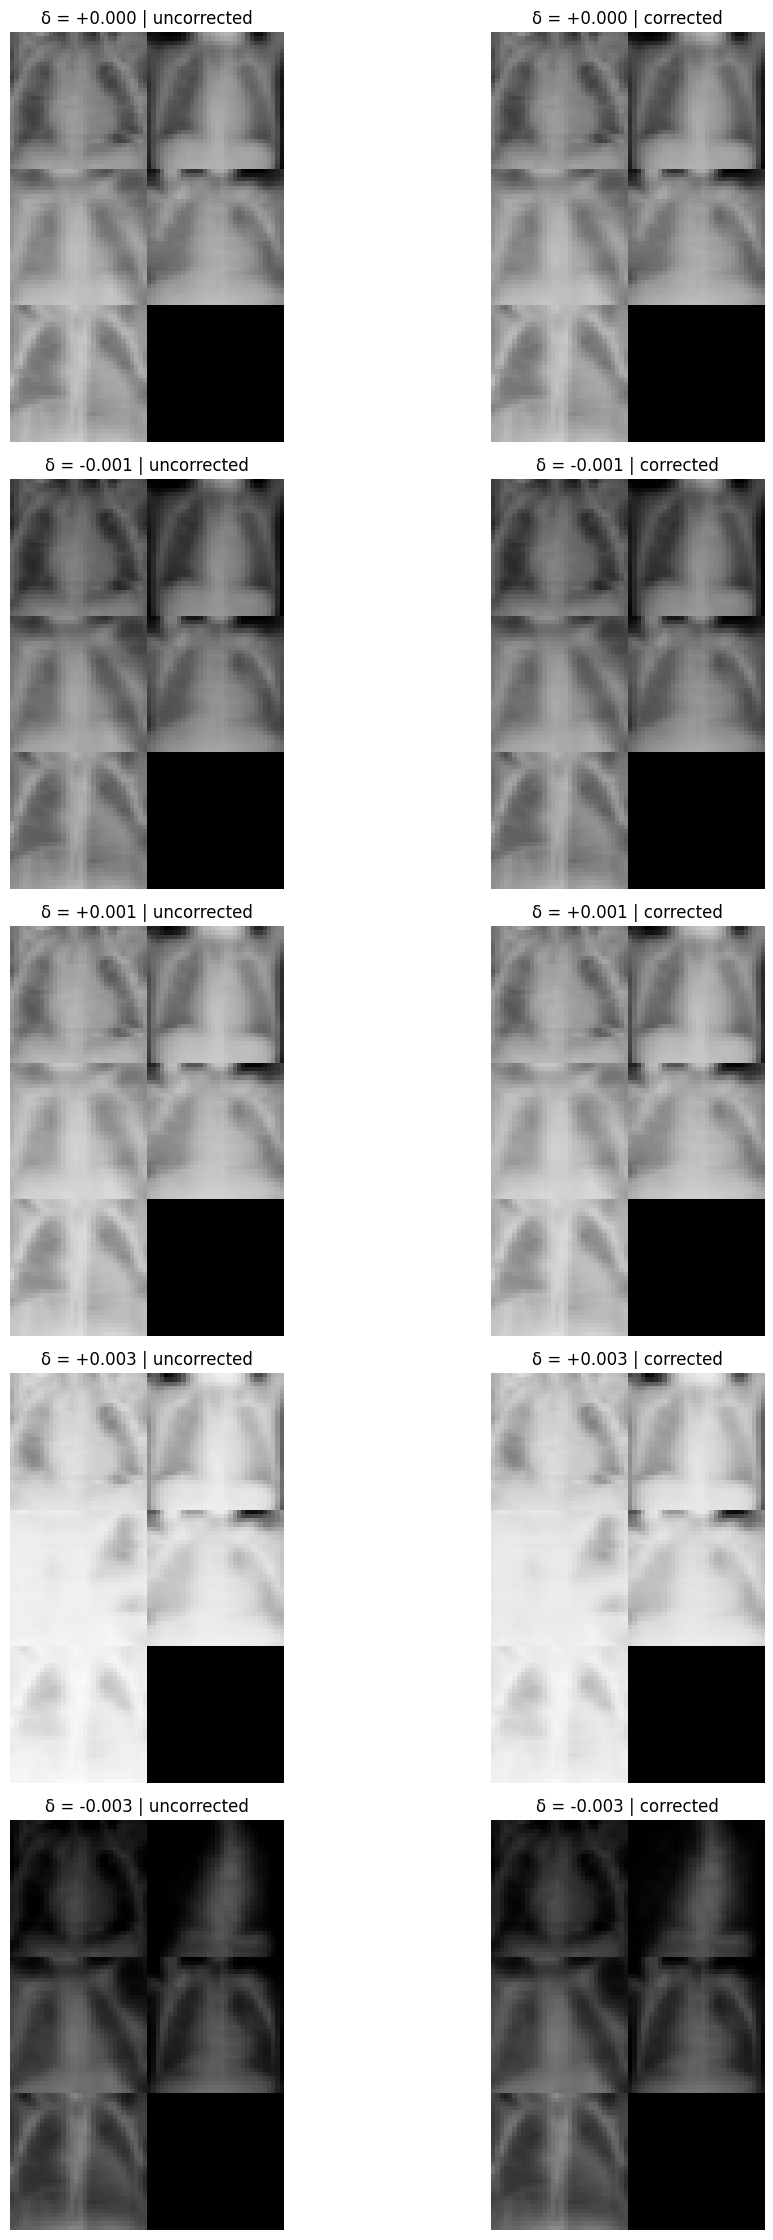

In [44]:
display_sampling_comparison([0.0, -0.001, 0.001, 0.003, -0.003])

In [7]:
!python -m training.run_delta_sweep \
  --deltas 0.1 \
  --base-output-dir /content/drive/MyDrive/XAI_project/outputs/experiments \
  --data-root /content/drive/MyDrive/XAI_project/data \
  --max-epochs 10 \
  --batch-size 128 \
  --num-workers 2 \
  --seed 42

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
2026-04-16 07:21:27.891046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776324087.918498   40101 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776324087.927742   40101 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776324087.961348   40101 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid link

In [8]:
!python -m sampling.run_visual_comparison \
  --deltas 0.1 \
  --base-output-dir /content/drive/MyDrive/XAI_project/outputs/experiments \
  --batch-size 5 \
  --class-label 0 \
  --seed 123

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Sampling delta=+0.100 | strategy=uncorrected
Checkpoint: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p100/train/diffusion_best.pt
Output dir: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p100/samples_uncorrected
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Sampling delta=+0.100 | strategy=corrected
Checkpoint: /content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p100/train/diffusion_best.pt
Output dir: /content/drive/MyDri

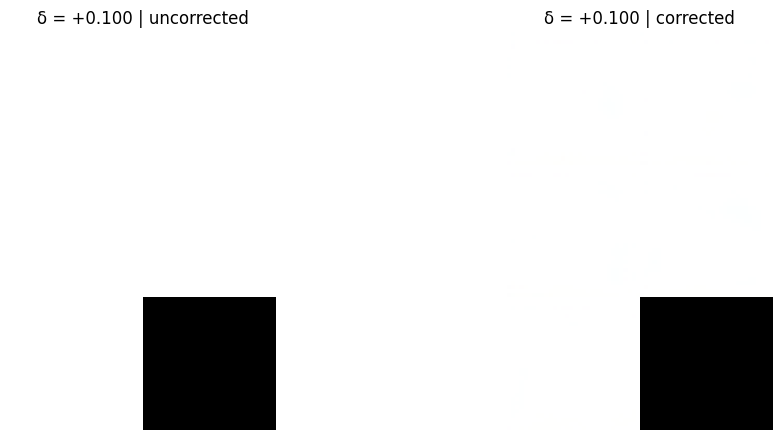

In [9]:
display_sampling_comparison([0.1])


samples_uncorrected
class_0_uncorrected_sample_000.png


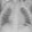

class_0_uncorrected_sample_001.png


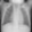

class_0_uncorrected_sample_002.png


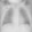

class_0_uncorrected_sample_003.png


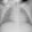

class_0_uncorrected_sample_004.png


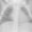


samples_corrected
class_0_corrected_sample_000.png


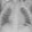

class_0_corrected_sample_001.png


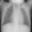

class_0_corrected_sample_002.png


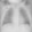

class_0_corrected_sample_003.png


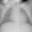

class_0_corrected_sample_004.png


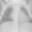

In [39]:
from IPython.display import Image, display
import os

base = "/content/drive/MyDrive/XAI_project/outputs/experiments/delta_plus_0p002"

for strategy in ["samples_uncorrected", "samples_corrected"]:
    print("\n" + "="*80)
    print(strategy)
    print("="*80)
    
    folder = os.path.join(base, strategy)
    files = sorted([f for f in os.listdir(folder) if f.endswith(".png") and "sample_" in f])
    
    for f in files:
        path = os.path.join(folder, f)
        print(f)
        display(Image(filename=path, width=256))

In [36]:
# Colab cell: mean difference between CIFAR-10 and PneumoniaMNIST (resized to 32x32)

!pip -q install medmnist

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import medmnist
from medmnist import INFO

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 512

# --- common transform to make both datasets comparable to the diffusion model ---
# CIFAR-10 is already 32x32 RGB.
# PneumoniaMNIST is grayscale, so we resize to 32x32 and repeat to 3 channels.
cifar_transform = transforms.ToTensor()

pneumonia_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),                 # -> [1, 32, 32]
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # -> [3, 32, 32]
])

# --- datasets ---
cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cifar_transform,
)

DataClass = getattr(medmnist, INFO["pneumoniamnist"]["python_class"])
pneumonia = DataClass(
    split="train",
    download=True,
    transform=pneumonia_transform,
)

cifar_loader = DataLoader(cifar, batch_size=batch_size, shuffle=False, num_workers=2)
pneumonia_loader = DataLoader(pneumonia, batch_size=batch_size, shuffle=False, num_workers=2)

def dataset_mean(loader):
    # channel-wise mean over all pixels in dataset
    pixel_sum = torch.zeros(3, dtype=torch.float64)
    pixel_count = 0

    for batch in loader:
        imgs = batch[0]  # ignore labels
        # imgs: [B, 3, H, W] in [0,1]
        pixel_sum += imgs.sum(dim=(0, 2, 3), dtype=torch.float64)
        pixel_count += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]

    return pixel_sum / pixel_count

cifar_mean = dataset_mean(cifar_loader)
pneumonia_mean = dataset_mean(pneumonia_loader)

signed_diff = pneumonia_mean - cifar_mean
abs_diff = signed_diff.abs()
mean_abs_diff_scalar = abs_diff.mean()

print("CIFAR-10 mean                :", cifar_mean.tolist())
print("PneumoniaMNIST mean (32x32)  :", pneumonia_mean.tolist())
print("Signed difference (P - C)    :", signed_diff.tolist())
print("Absolute difference          :", abs_diff.tolist())
print("Mean absolute difference     :", mean_abs_diff_scalar.item())

100%|██████████| 170M/170M [00:04<00:00, 39.7MB/s] 
100%|██████████| 4.17M/4.17M [00:06<00:00, 636kB/s]


CIFAR-10 mean                : [0.49139968987818966, 0.4821584196261869, 0.44653092422829765]
PneumoniaMNIST mean (32x32)  : [0.5719204328691196, 0.5719204328691196, 0.5719204328691196]
Signed difference (P - C)    : [0.08052074299092998, 0.08976201324293276, 0.125389508640822]
Absolute difference          : [0.08052074299092998, 0.08976201324293276, 0.125389508640822]
Mean absolute difference     : 0.0985574216248949


In [37]:
cifar_mean_pm1 = cifar_mean * 2 - 1
pneumonia_mean_pm1 = pneumonia_mean * 2 - 1
print("Mean abs diff in [-1,1] space:", (pneumonia_mean_pm1 - cifar_mean_pm1).abs().mean().item())

Mean abs diff in [-1,1] space: 0.1971148432497898


# Test

In [25]:
import os
import math
import json
import random
import numpy as np
import torch
from dataclasses import dataclass, asdict
from typing import Iterable
from diffusers import DDIMScheduler
from PIL import Image
from models.conditional_unet import build_class_conditional_unet_from_pretrained


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def denormalize_to_uint8(x: torch.Tensor) -> torch.Tensor:
    x = x.clamp(-1.0, 1.0)
    x = (x + 1.0) / 2.0
    x = (x * 255.0).round().to(torch.uint8)
    return x


def save_image_grid(images: torch.Tensor, save_path: str, nrow: int = 3, upscale: int = 8) -> None:
    """
    Save a grid of small images, enlarged for easier visual inspection.
    """
    ensure_dir(os.path.dirname(save_path))
    b, c, h, w = images.shape
    nrow = max(1, min(nrow, b))
    ncol = math.ceil(b / nrow)

    H = h * upscale
    W = w * upscale
    mode = "RGB" if c == 3 else "L"
    grid = Image.new(mode, (nrow * W, ncol * H))

    for idx in range(b):
        img = images[idx].permute(1, 2, 0).cpu().numpy()
        if c == 1:
            img = img[..., 0]
        pil_img = Image.fromarray(img).resize((W, H), resample=Image.NEAREST)
        x0 = (idx % nrow) * W
        y0 = (idx // nrow) * H
        grid.paste(pil_img, (x0, y0))

    grid.save(save_path)


def get_alpha_bar_prev(scheduler: DDIMScheduler, timesteps: torch.Tensor, step_idx: int, device: str):
    if step_idx + 1 < len(timesteps):
        prev_t = int(timesteps[step_idx + 1].item())
        return scheduler.alphas_cumprod[prev_t].to(device)
    return scheduler.final_alpha_cumprod.to(device)


def delta_to_name(delta: float) -> str:
    s = f"{delta:+.3f}"
    return s.replace("+", "plus_").replace("-", "minus_").replace(".", "p")


@dataclass
class DefaultSampleConfig:
    pretrained_repo_id: str = "google/ddpm-cifar10-32"
    output_dir: str = "/content/drive/MyDrive/XAI_project/outputs/default_model_experiments"

    num_classes: int = 2
    image_size: int = 32
    num_channels: int = 3

    delta: float = 0.0
    use_corrected: bool = True

    num_inference_steps: int = 50
    num_train_timesteps: int = 1000
    batch_size: int = 5
    class_label: int = 0
    seed: int = 123

    device: str = "cuda" if torch.cuda.is_available() else "cpu"


@torch.no_grad()
def sample_default_model(cfg: DefaultSampleConfig) -> torch.Tensor:
    set_seed(cfg.seed)

    model, load_info = build_class_conditional_unet_from_pretrained(
        repo_id=cfg.pretrained_repo_id,
        num_classes=cfg.num_classes,
        device=cfg.device,
    )
    model.eval()

    scheduler = DDIMScheduler(num_train_timesteps=cfg.num_train_timesteps)
    scheduler.set_timesteps(cfg.num_inference_steps)

    x = torch.randn(
        cfg.batch_size,
        cfg.num_channels,
        cfg.image_size,
        cfg.image_size,
        device=cfg.device,
    )

    # Your chosen convention
    delta_tensor = torch.full_like(x, fill_value=cfg.delta)
    x = x + delta_tensor

    class_labels = torch.full(
        (cfg.batch_size,),
        fill_value=cfg.class_label,
        device=cfg.device,
        dtype=torch.long,
    )

    timesteps = scheduler.timesteps

    for step_idx, t in enumerate(timesteps):
        noise_pred = model(x, t, class_labels=class_labels).sample
        step_output = scheduler.step(noise_pred, t, x)
        x = step_output.prev_sample

        if cfg.use_corrected:
            alpha_bar_prev = get_alpha_bar_prev(scheduler, timesteps, step_idx, x.device)
            x = x + delta_tensor * torch.sqrt(1.0 - alpha_bar_prev)
        else:
            x = x + delta_tensor

    return x, load_info


def generate_and_save_default_samples(cfg: DefaultSampleConfig):
    ensure_dir(cfg.output_dir)

    samples, load_info = sample_default_model(cfg)
    samples_uint8 = denormalize_to_uint8(samples)

    strategy_name = "corrected" if cfg.use_corrected else "uncorrected"

    with open(os.path.join(cfg.output_dir, "sample_config.json"), "w", encoding="utf-8") as f:
        json.dump(asdict(cfg), f, indent=2)

    with open(os.path.join(cfg.output_dir, "pretrained_load_info.json"), "w", encoding="utf-8") as f:
        json.dump(load_info, f, indent=2)

    grid_path = os.path.join(
        cfg.output_dir,
        f"samples_class_{cfg.class_label}_{strategy_name}_grid.png",
    )
    save_image_grid(samples_uint8, grid_path, nrow=3, upscale=8)

    saved = [grid_path]
    for i in range(samples_uint8.shape[0]):
        img = samples_uint8[i].permute(1, 2, 0).cpu().numpy()
        if samples_uint8.shape[1] == 1:
            img = img[..., 0]
        img_path = os.path.join(
            cfg.output_dir,
            f"class_{cfg.class_label}_{strategy_name}_sample_{i:03d}.png",
        )
        Image.fromarray(img).save(img_path)
        saved.append(img_path)

    return saved

In [26]:
DEFAULT_DELTAS = [0.0, 0.1, -0.1, 0.003, -0.003, 0.01, -0.01]

base_output_dir = "/content/drive/MyDrive/XAI_project/outputs/default_model_experiments"
ensure_dir(base_output_dir)

summary = []

for delta in DEFAULT_DELTAS:
    run_name = f"delta_{delta_to_name(delta)}"
    for use_corrected in [False, True]:
        strategy_name = "corrected" if use_corrected else "uncorrected"
        output_dir = os.path.join(base_output_dir, run_name, f"samples_{strategy_name}")

        cfg = DefaultSampleConfig(
            output_dir=output_dir,
            delta=delta,
            use_corrected=use_corrected,
            batch_size=5,
            class_label=0,
            seed=123,
        )

        print("=" * 80)
        print(f"Default model | delta={delta:+.3f} | strategy={strategy_name}")
        print(f"Output dir: {output_dir}")
        print("=" * 80)

        saved_paths = generate_and_save_default_samples(cfg)
        summary.append(
            {
                "delta": delta,
                "strategy": strategy_name,
                "output_dir": output_dir,
                "saved_paths": saved_paths,
            }
        )

with open(os.path.join(base_output_dir, "summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Done.")

Default model | delta=+0.000 | strategy=uncorrected
Output dir: /content/drive/MyDrive/XAI_project/outputs/default_model_experiments/delta_plus_0p000/samples_uncorrected
Default model | delta=+0.000 | strategy=corrected
Output dir: /content/drive/MyDrive/XAI_project/outputs/default_model_experiments/delta_plus_0p000/samples_corrected
Default model | delta=+0.100 | strategy=uncorrected
Output dir: /content/drive/MyDrive/XAI_project/outputs/default_model_experiments/delta_plus_0p100/samples_uncorrected
Default model | delta=+0.100 | strategy=corrected
Output dir: /content/drive/MyDrive/XAI_project/outputs/default_model_experiments/delta_plus_0p100/samples_corrected
Default model | delta=-0.100 | strategy=uncorrected
Output dir: /content/drive/MyDrive/XAI_project/outputs/default_model_experiments/delta_minus_0p100/samples_uncorrected
Default model | delta=-0.100 | strategy=corrected
Output dir: /content/drive/MyDrive/XAI_project/outputs/default_model_experiments/delta_minus_0p100/samples_

In [27]:
import matplotlib.pyplot as plt
from PIL import Image

def display_default_model_comparison(
    deltas,
    base_output_dir="/content/drive/MyDrive/XAI_project/outputs/default_model_experiments",
    class_label=0,
):
    deltas = list(deltas)
    fig, axes = plt.subplots(len(deltas), 2, figsize=(12, 4.5 * len(deltas)), squeeze=False)

    for row_idx, delta in enumerate(deltas):
        run_name = f"delta_{delta_to_name(delta)}"
        paths = {
            "uncorrected": os.path.join(
                base_output_dir,
                run_name,
                "samples_uncorrected",
                f"samples_class_{class_label}_uncorrected_grid.png",
            ),
            "corrected": os.path.join(
                base_output_dir,
                run_name,
                "samples_corrected",
                f"samples_class_{class_label}_corrected_grid.png",
            ),
        }

        for col_idx, (strategy, path) in enumerate(paths.items()):
            ax = axes[row_idx][col_idx]
            if os.path.exists(path):
                ax.imshow(Image.open(path))
                ax.set_title(f"default model | δ={delta:+.3f} | {strategy}")
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

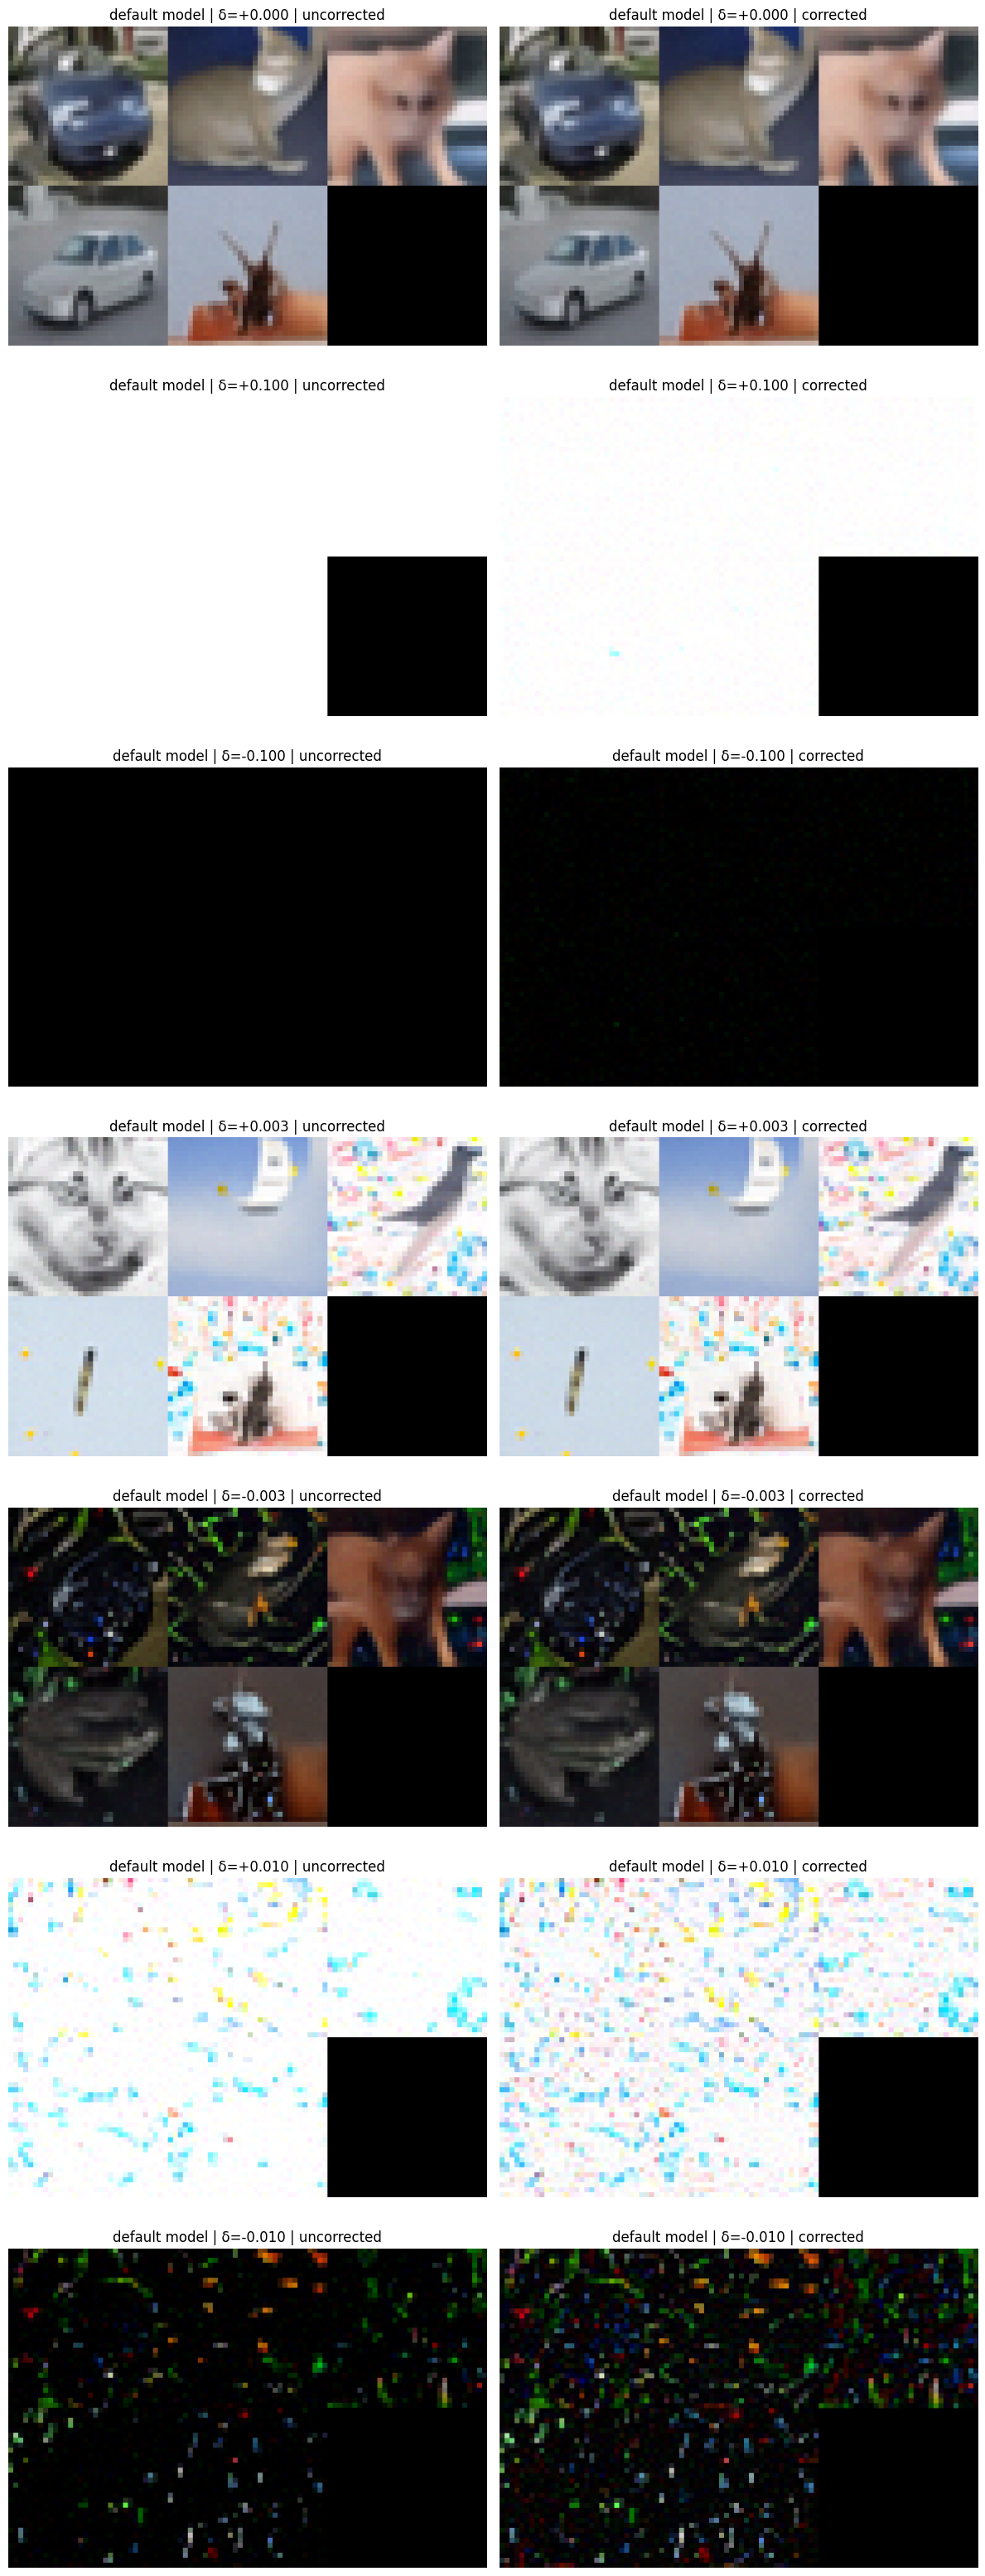

In [28]:
display_default_model_comparison(DEFAULT_DELTAS)